In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta
from matplotlib.patches import Rectangle, FancyBboxPatch
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

# flex needs

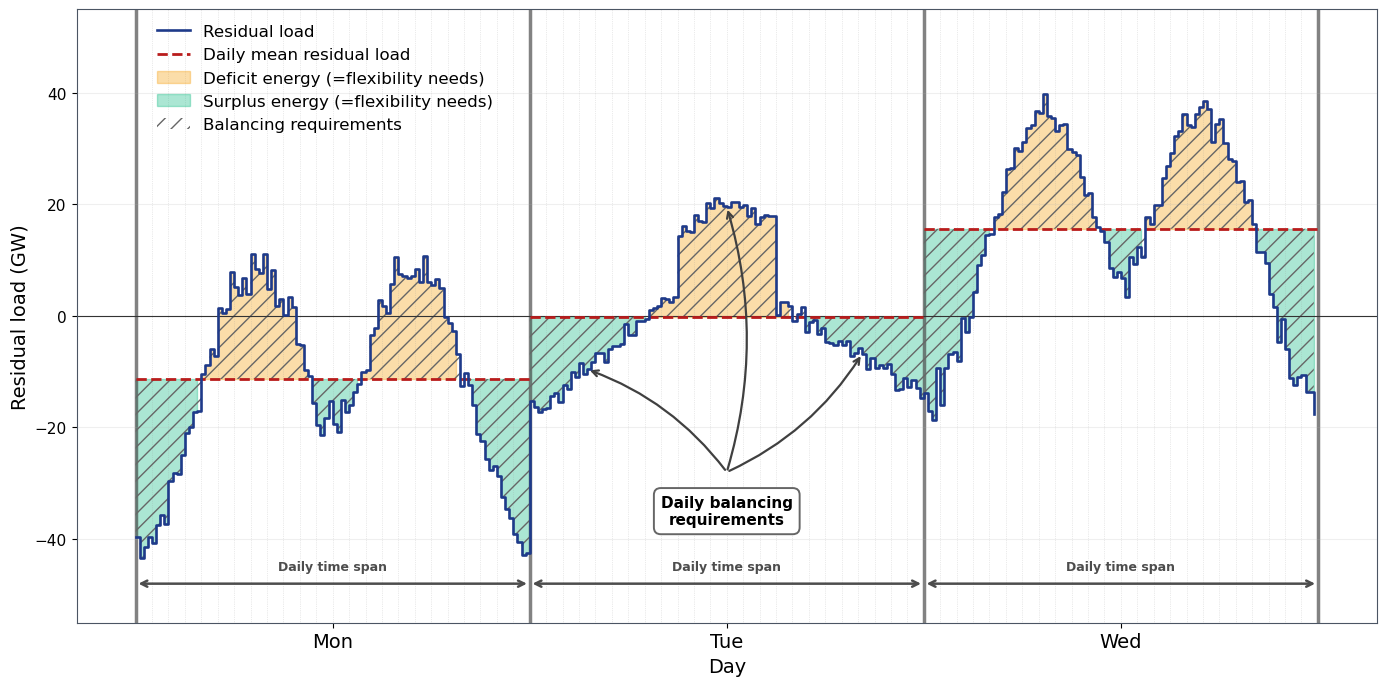

In [2]:
# -----------------------
# Data (deterministic)
# -----------------------
np.random.seed(7)
start = pd.Timestamp('2019-01-01 00:00')
end   = pd.Timestamp('2019-01-03 23:45')
t = pd.date_range(start, end, freq='15min')
day  = (t - t[0]).days
hour = t.hour + t.minute / 60
hrs  = (t - t[0]).total_seconds() / 3600
res = np.zeros(len(t))
for i, (d, h) in enumerate(zip(day, hour)):
    if d == 1:
        if h < 9:
            res[i] = -18 + 2.5*h + np.random.normal(0, 1.2)
        elif h < 15:
            res[i] = 15 + 6*np.sin(np.pi*(h-9)/6) + np.random.normal(0, 1.2)
        else:
            res[i] = 2 - 1.8*(h-15) + np.random.normal(0, 1.2)
    else:
        daily = 18*np.sin(2*np.pi*(h-6)/24) + 10*np.sin(4*np.pi*(h-3)/24)
        solar = -28*np.exp(-((h-12)**2)/8)
        wind  = 15*np.sin(2*np.pi*hrs[i]/48)
        base  = -15 if d == 0 else 12
        res[i] = daily + solar + wind + base + np.random.normal(0, 2)
res = pd.Series(np.clip(res, -50, 50), index=t)
daily_mean = res.resample('D').transform('mean')

# -----------------------
# Figure setup
# -----------------------
plt.rcParams.update({
    'font.size': 11,
    'axes.linewidth': 0.8,
    'axes.edgecolor': '#4B5563'
})
fig, ax = plt.subplots(figsize=(14, 7))
c_res  = '#1E3A8A'
c_pos  = '#F59E0B'
c_neg  = '#10B981'
c_mean = '#B91C1C'

# -----------------------
# Main plot
# -----------------------
ax.step(t, res, where='post', lw=1.9, color=c_res,
        label='Residual load', zorder=4)
for d, v in res.resample('D').mean().items():
    ax.plot([d, d + timedelta(days=1)], [v, v],
            '--', lw=2.0, color=c_mean, zorder=3)
ax.plot([], [], '--', lw=2.0, color=c_mean,
        label='Daily mean residual load')
ax.fill_between(t, daily_mean, res, where=res >= daily_mean,
                step='post', color=c_pos, alpha=0.35,
                label='Deficit energy (=flexibility needs)')
ax.fill_between(t, res, daily_mean, where=res < daily_mean,
                step='post', color=c_neg, alpha=0.35,
                label='Surplus energy (=flexibility needs)')
ax.fill_between(t, daily_mean, res, step='post',
                facecolor='none', hatch='//',
                edgecolor='0.4', lw=0.0,
                label='Balancing requirements', zorder=2)

# -----------------------
# Axes formatting
# -----------------------
# Big vertical lines at the start and end of each day
day_boundaries = pd.date_range(start, end + timedelta(days=1), freq='D')
for d in day_boundaries:
    ax.axvline(d, ls='-', lw=2.5, color='0.3', alpha=0.7, zorder=1)

# Hourly ticks (thin lines)
for h in pd.date_range(start, end, freq='h'):
    if h.hour == 0:  # Skip midnight (already handled by day separator)
        continue
    ax.axvline(h, ls=':', lw=0.5, color='0.6', alpha=0.4, zorder=1)

ax.axhline(0, color='0.2', lw=0.8)
ax.set(
    ylim=(-55, 55),
)
# Set labels and title with larger font sizes
ax.set_ylabel('Residual load (GW)', fontsize=14)
ax.set_xlabel('Day', fontsize=14)
# ax.set_title('Daily flexibility needs', fontsize=16, fontweight='bold', pad=15)

ax.set_xticks([start + timedelta(hours=12),
               start + timedelta(days=1, hours=12),
               start + timedelta(days=2, hours=12)])
ax.set_xticklabels(['Mon', 'Tue', 'Wed'], fontsize=14)
ax.grid(axis='y', alpha=0.2)

# Move legend slightly to the right using bbox_to_anchor
ax.legend(loc='upper left', frameon=False, bbox_to_anchor=(0.05, 1.0), fontsize=12)

# -----------------------
# Annotation (Tuesday)
# -----------------------
d2s = start + timedelta(days=1)
d2e = start + timedelta(days=2)
mask = (t >= d2s) & (t < d2e)
t2, v2 = t[mask], res[mask]
idx = [int(0.15*len(t2)), int(0.5*len(t2)), int(0.85*len(t2))]
targets = [(t2[i], v2.iloc[i]) for i in idx]
anchor_x = d2s + (d2e - d2s) / 2
anchor_y = -28

ax.annotate('Daily balancing\nrequirements',
            xy=targets[1],
            xytext=(anchor_x, -35),
            ha='center', va='center',
            weight='bold',
            bbox=dict(boxstyle='round,pad=0.45',
                      facecolor='white',
                      edgecolor='0.4',
                      lw=1.4))
for tx, ty in targets:
    ax.annotate('', xy=(tx, ty),
                xytext=(anchor_x, anchor_y),
                arrowprops=dict(arrowstyle='->',
                                lw=1.6,
                                connectionstyle='arc3,rad=0.15',
                                color='0.25'))

# -----------------------
# Daily time span brackets (at bottom for all days)
# -----------------------
bracket_y = -48  # Y position for the brackets (near bottom)
bracket_text_y = -46  # Y position for the text ABOVE brackets (changed from -52)

# Create brackets for all 3 days
day_starts = pd.date_range(start, end, freq='D')
day_names = ['Mon', 'Tue', 'Wed']

for i, (day_start, day_name) in enumerate(zip(day_starts[:3], day_names)):
    day_end = day_start + timedelta(days=1)
    day_center = day_start + timedelta(hours=12)
    
    # Draw horizontal line with arrows at the ends
    ax.annotate('', xy=(day_start, bracket_y), xytext=(day_end, bracket_y),
                arrowprops=dict(arrowstyle='<->', lw=1.8, color='0.3'))
    
    # Add text ABOVE the bracket
    ax.text(day_center, bracket_text_y, 'Daily time span',
            ha='center', va='bottom', fontsize=9, weight='bold', color='0.3')

plt.tight_layout()
plt.savefig('/home/julian-geis/Documents/06_PhD/02Flexibility/plots/methods/daily_flexibility_needs.png', dpi=300, bbox_inches='tight')
plt.show()

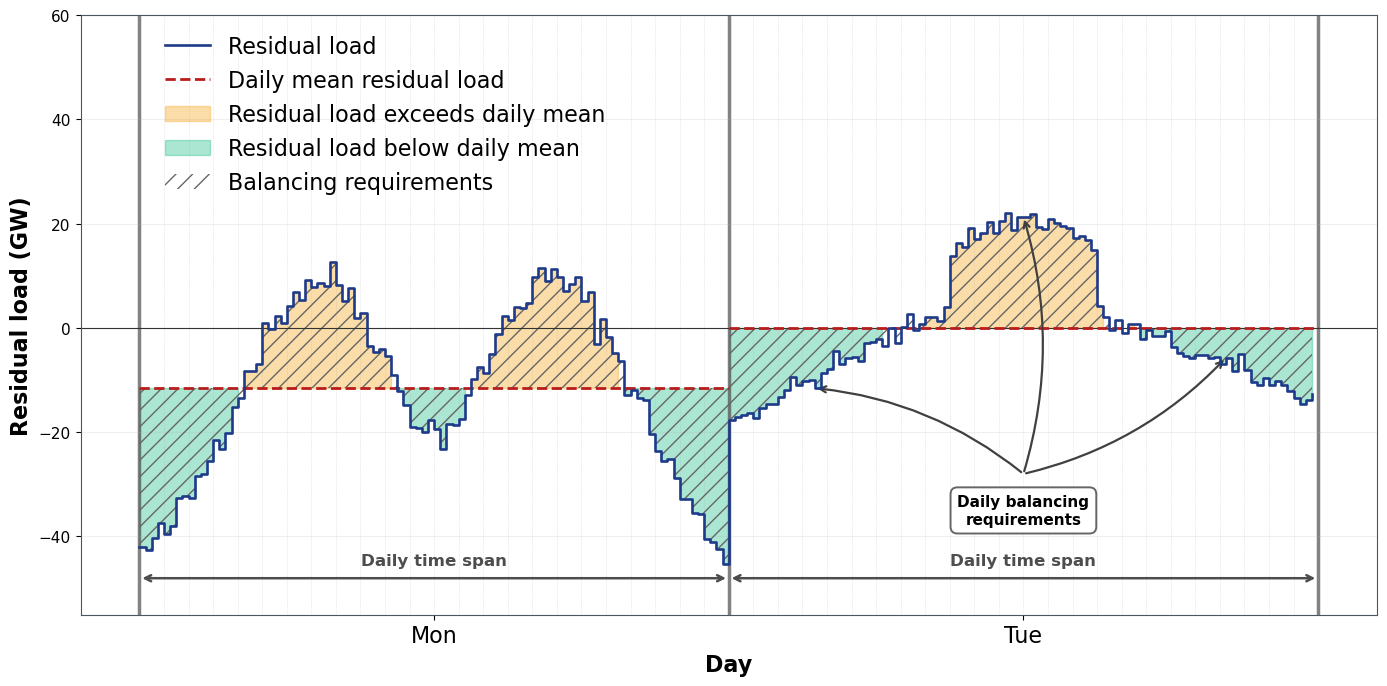

In [ ]:
# -----------------------
# Data (deterministic) - ONLY 2 DAYS
# -----------------------
np.random.seed(42)
start = pd.Timestamp('2019-01-01 00:00')
end   = pd.Timestamp('2019-01-02 23:45')  # Changed from 01-03 to 01-02
t = pd.date_range(start, end, freq='15min')
day  = (t - t[0]).days
hour = t.hour + t.minute / 60
hrs  = (t - t[0]).total_seconds() / 3600
res = np.zeros(len(t))
for i, (d, h) in enumerate(zip(day, hour)):
    if d == 1:
        if h < 9:
            res[i] = -18 + 2.5*h + np.random.normal(0, 1.2)
        elif h < 15:
            res[i] = 15 + 6*np.sin(np.pi*(h-9)/6) + np.random.normal(0, 1.2)
        else:
            res[i] = 2 - 1.8*(h-15) + np.random.normal(0, 1.2)
    else:
        daily = 18*np.sin(2*np.pi*(h-6)/24) + 10*np.sin(4*np.pi*(h-3)/24)
        solar = -28*np.exp(-((h-12)**2)/8)
        wind  = 15*np.sin(2*np.pi*hrs[i]/48)
        base  = -15 if d == 0 else 12
        res[i] = daily + solar + wind + base + np.random.normal(0, 2)
res = pd.Series(np.clip(res, -50, 50), index=t)
daily_mean = res.resample('D').transform('mean')

# -----------------------
# Figure setup
# -----------------------
plt.rcParams.update({
    'font.size': 11,
    'axes.linewidth': 0.8,
    'axes.edgecolor': '#4B5563'
})
fig, ax = plt.subplots(figsize=(14, 7))
c_res  = '#1E3A8A'
c_pos  = '#F59E0B'
c_neg  = '#10B981'
c_mean = '#B91C1C'

# -----------------------
# Main plot
# -----------------------
ax.step(t, res, where='post', lw=1.9, color=c_res,
        label='Residual load', zorder=4)
for d, v in res.resample('D').mean().items():
    ax.plot([d, d + timedelta(days=1)], [v, v],
            '--', lw=2.0, color=c_mean, zorder=3)
ax.plot([], [], '--', lw=2.0, color=c_mean,
        label='Daily mean residual load')
ax.fill_between(t, daily_mean, res, where=res >= daily_mean,
                step='post', color=c_pos, alpha=0.35,
                label='Residual load exceeds daily mean')
ax.fill_between(t, res, daily_mean, where=res < daily_mean,
                step='post', color=c_neg, alpha=0.35,
                label='Residual load below daily mean')
ax.fill_between(t, daily_mean, res, step='post',
                facecolor='none', hatch='//',
                edgecolor='0.4', lw=0.0,
                label='Balancing requirements', zorder=2)

# -----------------------
# Axes formatting
# -----------------------
# Big vertical lines at the start and end of each day
day_boundaries = pd.date_range(start, end + timedelta(days=1), freq='D')
for d in day_boundaries:
    ax.axvline(d, ls='-', lw=2.5, color='0.3', alpha=0.7, zorder=1)

# Hourly ticks (thin lines)
for h in pd.date_range(start, end, freq='h'):
    if h.hour == 0:  # Skip midnight (already handled by day separator)
        continue
    ax.axvline(h, ls=':', lw=0.5, color='0.6', alpha=0.4, zorder=1)

ax.axhline(0, color='0.2', lw=0.8)
ax.set(
    ylim=(-55, 55),
)
# Set labels and title with larger font sizes
ax.set_ylabel('Residual load (GW)', fontsize=16, fontweight='bold')
ax.set_xlabel('Day', fontsize=16, fontweight='bold')
# ax.set_title('Daily flexibility needs', fontsize=16, fontweight='bold', pad=15)

ax.set_xticks([start + timedelta(hours=12),
               start + timedelta(days=1, hours=12)])  # Only 2 days
ax.set_xticklabels(['Mon', 'Tue'], fontsize=16)  # Only Mon and Tue
ax.grid(axis='y', alpha=0.2)

# Move legend slightly to the right using bbox_to_anchor
ax.legend(loc='upper left', frameon=False, bbox_to_anchor=(0.05, 1.0), fontsize=16)

# -----------------------
# Annotation (Tuesday)
# -----------------------
d2s = start + timedelta(days=1)
d2e = start + timedelta(days=2)
mask = (t >= d2s) & (t < d2e)
t2, v2 = t[mask], res[mask]
idx = [int(0.15*len(t2)), int(0.5*len(t2)), int(0.85*len(t2))]
targets = [(t2[i], v2.iloc[i]) for i in idx]
anchor_x = d2s + (d2e - d2s) / 2
anchor_y = -28

ax.annotate('Daily balancing\nrequirements',
            xy=targets[1],
            xytext=(anchor_x, -35),
            ha='center', va='center',
            weight='bold',
            bbox=dict(boxstyle='round,pad=0.45',
                      facecolor='white',
                      edgecolor='0.4',
                      lw=1.4))
for tx, ty in targets:
    ax.annotate('', xy=(tx, ty),
                xytext=(anchor_x, anchor_y),
                arrowprops=dict(arrowstyle='->',
                                lw=1.6,
                                connectionstyle='arc3,rad=0.15',
                                color='0.25'))

# -----------------------
# Daily time span brackets (at bottom for all days)
# -----------------------
bracket_y = -48  # Y position for the brackets (near bottom)
bracket_text_y = -46  # Y position for the text ABOVE brackets

# Create brackets for only 2 days
day_starts = pd.date_range(start, end, freq='D')
day_names = ['Mon', 'Tue']  # Only 2 days

for i, (day_start, day_name) in enumerate(zip(day_starts[:2], day_names)):  # Only first 2
    day_end = day_start + timedelta(days=1)
    day_center = day_start + timedelta(hours=12)
    
    # Draw horizontal line with arrows at the ends
    ax.annotate('', xy=(day_start, bracket_y), xytext=(day_end, bracket_y),
                arrowprops=dict(arrowstyle='<->', lw=1.8, color='0.3'))
    
    # Add text ABOVE the bracket
    ax.text(day_center, bracket_text_y, 'Daily time span',
            ha='center', va='bottom', fontsize=12, weight='bold', color='0.3')

plt.tight_layout()
plt.savefig('/home/julian-geis/Documents/06_PhD/02Flexibility/plots/methods/daily_flexibility_needs_two_days.png', dpi=300, bbox_inches='tight')
plt.show()

# flex contributions

Daily flexibility needs: 60.0 GWh
Solar flexibility contribution: 9.0 GWh
Gas flexibility contribution: 19.5 GWh

✓ Flexibility provision plot saved

Calculations:
Daily flexibility needs = 0.5 × (|36-44| + |48-44| + |52-44| + |46-44| + |42-44| + |38-44| + |50-44| + |40-44|) × 3h = 60.0 GWh
Solar flexibility contribution = 0.5 × (-4×-1 + -4×+1 + +0×+1 + +10×+1 + +6×-1 + -2×-1 + -4×+1 + -4×-1) × 3h = 9.0 GWh
Gas flexibility contribution = 0.5 × (-3×-1 + +1×+1 + +3×+1 + +0×+1 + -1×-1 + -2×-1 + +2×+1 + -1×-1) × 3h = 19.5 GWh


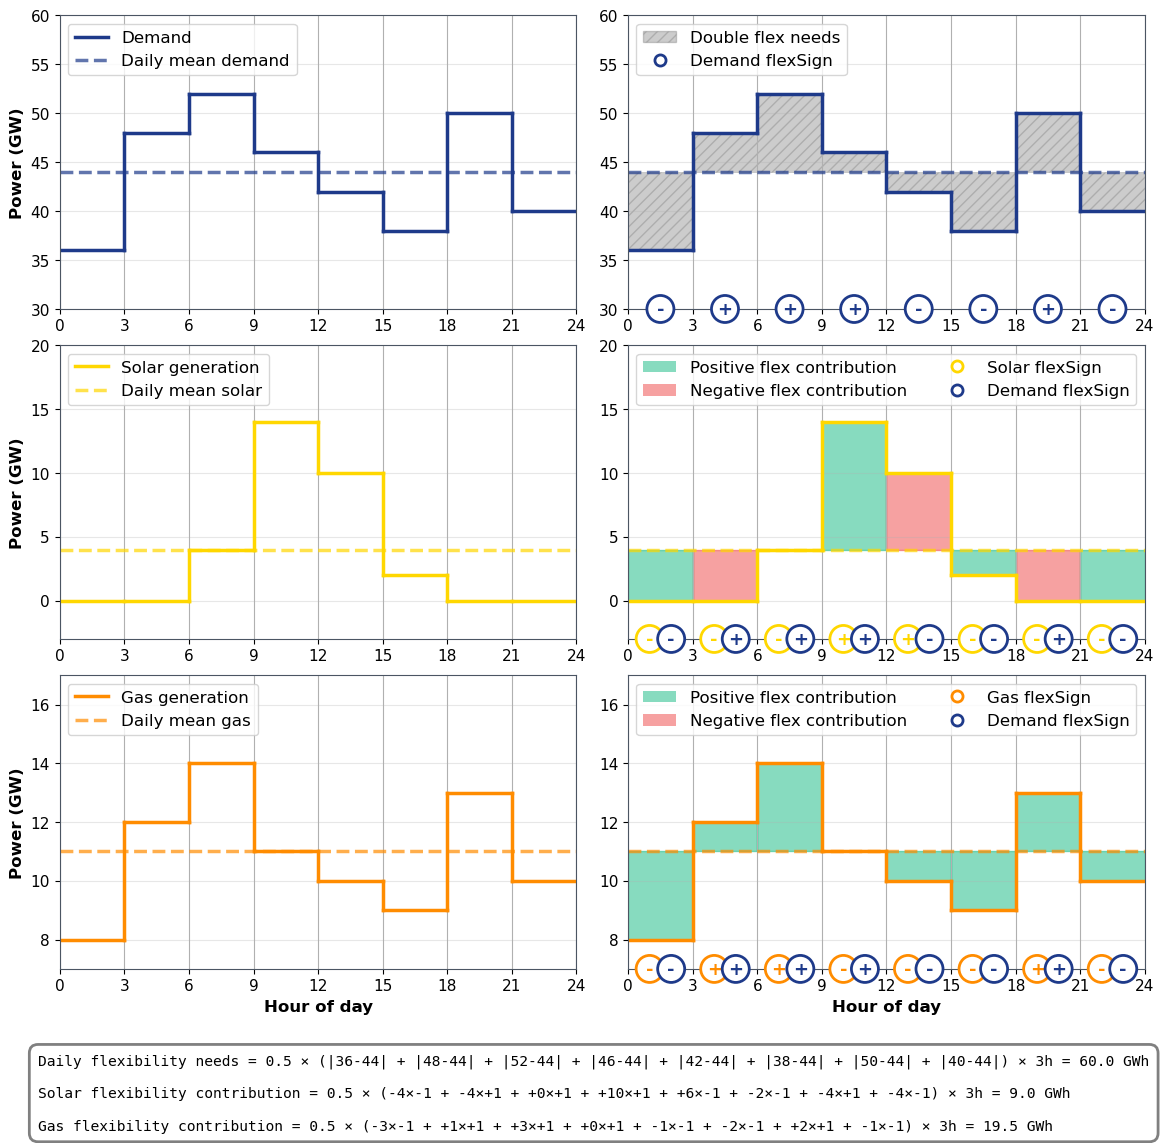

In [39]:
# -----------------------
# Data setup - 3 hour resolution for one day
# -----------------------
np.random.seed(42)
start = pd.Timestamp('2019-01-01 00:00')
end = pd.Timestamp('2019-01-01 21:00')
t = pd.date_range(start, end, freq='3h')
hour = t.hour

# Net demand (residual load) - morning and evening peaks with cleaner numbers
net_demand = np.array([36, 48, 52, 46, 42, 38, 50, 40])  # Clean values in GW
net_demand = pd.Series(net_demand, index=t)
net_demand_mean = net_demand.mean()  # Will be 44.0 GW

# Solar generation - only from 6h to 18h (zero otherwise) - clean numbers
solar = np.array([0, 0, 4, 14, 10, 2, 0, 0])  # Clean values, mean = 3.75 ≈ 4.0
solar = pd.Series(solar, index=t)
solar_mean = 4.0  # Set to clean number

# Gas generation - follows net demand with clean numbers
gas = np.array([8, 12, 14, 11, 10, 9, 13, 10])  # Mean = 10.875 ≈ 11.0
gas = pd.Series(gas, index=t)
gas_mean = 11.0  # Set to clean number

# Calculate flexibility sign from net demand
flex_sign = np.sign(net_demand - net_demand_mean)
prod_sign_solar = np.sign(solar - solar_mean)
prod_sign_gas = np.sign(gas - gas_mean)

# Calculate flexibility needs (net demand) in GWh
flex_needs = 0.5 * np.sum(np.abs(net_demand - net_demand_mean)) * 3  # GWh

# Calculate flexibility contributions in GWh
solar_flex_curve = (solar - solar_mean) * flex_sign
gas_flex_curve = (gas - gas_mean) * flex_sign

solar_contribution = 0.5 * np.sum(solar_flex_curve) * 3   # GWh (×3 for 3h intervals)
gas_contribution = 0.5 * np.sum(gas_flex_curve) * 3   # GWh

print(f"Daily flexibility needs: {flex_needs:.1f} GWh")
print(f"Solar flexibility contribution: {solar_contribution:.1f} GWh")
print(f"Gas flexibility contribution: {gas_contribution:.1f} GWh")

# Helper function to format numbers without trailing .0
def format_num(val):
    if val == int(val):
        return f"{int(val)}"
    else:
        return f"{val:.1f}"

# Helper function to add sign to string
def format_with_sign(val):
    num_str = format_num(abs(val))
    if val >= 0:
        return f"+{num_str}"
    else:
        return f"-{num_str}"

# Build calculation strings
flex_needs_calc = "Daily flexibility needs = 0.5 × ("
for i in range(len(hour)):
    nd_val = format_num(net_demand.iloc[i])
    mean_val = format_num(net_demand_mean)
    flex_needs_calc += f"|{nd_val}-{mean_val}|"
    if i < len(hour) - 1:
        flex_needs_calc += " + "
flex_needs_calc += f") × 3h = {flex_needs:.1f} GWh"

solar_calc = "Solar flexibility contribution = 0.5 × ("
for i in range(len(hour)):
    prod_val = solar.iloc[i] - solar_mean
    sign_val = int(flex_sign.iloc[i])
    prod_str = format_with_sign(prod_val)
    solar_calc += f"{prod_str}×{sign_val:+d}"
    if i < len(hour) - 1:
        solar_calc += " + "
solar_calc += f") × 3h = {solar_contribution:.1f} GWh"

gas_calc = "Gas flexibility contribution = 0.5 × ("
for i in range(len(hour)):
    prod_val = gas.iloc[i] - gas_mean
    sign_val = int(flex_sign.iloc[i])
    prod_str = format_with_sign(prod_val)
    gas_calc += f"{prod_str}×{sign_val:+d}"
    if i < len(hour) - 1:
        gas_calc += " + "
gas_calc += f") × 3h = {gas_contribution:.1f} GWh"

# -----------------------
# Create the plot
# -----------------------
plt.rcParams.update({
    'font.size': 11,
    'axes.linewidth': 0.8,
})

fig = plt.figure(figsize=(14, 14))
gs = fig.add_gridspec(4, 2, hspace=0.15, wspace=0.1, height_ratios=[1, 1, 1, 0.3])
axes = [[fig.add_subplot(gs[i, j]) for j in range(2)] for i in range(3)]

# Colors
c_net = '#1E3A8A'
c_solar = '#FFD700'  # Gold
c_gas = '#FF8C00'    # Dark orange
c_pos = '#10B981'  # Green for positive
c_neg = '#EF4444'  # Red for negative

# -----------------------
# Row 1: Net demand
# -----------------------
ax1 = axes[0][0]
# Plot as step function with proper 3h intervals
for i in range(len(hour)):
    if i < len(hour) - 1:
        ax1.plot([hour[i], hour[i+1]], [net_demand.iloc[i], net_demand.iloc[i]], 
                lw=2.5, color=c_net)
        ax1.plot([hour[i+1], hour[i+1]], [net_demand.iloc[i], net_demand.iloc[i+1]], 
                lw=2.5, color=c_net)
    else:
        # Last segment
        ax1.plot([hour[i], 24], [net_demand.iloc[i], net_demand.iloc[i]], 
                lw=2.5, color=c_net)

ax1.plot([], [], lw=2.5, color=c_net, label='Demand')
ax1.axhline(net_demand_mean, ls='--', lw=2.5, color=c_net, alpha=0.7, label='Daily mean demand')

ax1.set_ylabel('Power (GW)', fontsize=12, fontweight='bold')
ax1.set_xlabel('')  # Remove label but keep values
ax1.legend(loc='upper left', frameon=True, ncol=1, fontsize=12)
ax1.grid(axis='y', alpha=0.3)
ax1.set_xlim(0, 24)
ax1.set_xticks(range(0, 25, 3))
demand_ylim = (30, 60)
ax1.set_ylim(demand_ylim)
ax1.grid(True)

# Right panel: flexSign with shaded flex needs areas
ax1r = axes[0][1]
# Plot as step function
for i in range(len(hour)):
    if i < len(hour) - 1:
        ax1r.plot([hour[i], hour[i+1]], [net_demand.iloc[i], net_demand.iloc[i]], 
                 lw=2.5, color=c_net)
        ax1r.plot([hour[i+1], hour[i+1]], [net_demand.iloc[i], net_demand.iloc[i+1]], 
                 lw=2.5, color=c_net)
    else:
        ax1r.plot([hour[i], 24], [net_demand.iloc[i], net_demand.iloc[i]], 
                 lw=2.5, color=c_net)

ax1r.axhline(net_demand_mean, ls='--', lw=2.5, color=c_net, alpha=0.7)

# Shade flexibility needs areas
y_label = demand_ylim[0]  # Position at bottom
for i in range(len(hour)):
    h_start = hour[i]
    h_end = hour[i+1] if i < len(hour) - 1 else 24
    h_center = (h_start + h_end) / 2
    nd = net_demand.iloc[i]
    
    # Shade the area between net demand and mean (flex needs)
    ax1r.fill_between([h_start, h_end], [net_demand_mean, net_demand_mean], [nd, nd],
                      alpha=0.4, color='gray', hatch='///', edgecolor='gray', linewidth=0.5)
    
    # Add +/- labels at bottom of each 3h interval (BLUE circles, smaller)
    sign = '+' if flex_sign.iloc[i] > 0 else '-'
    ax1r.text(h_center, y_label, sign, ha='center', va='center', fontsize=13, 
              fontweight='bold', color=c_net,
              bbox=dict(boxstyle='circle,pad=0.25', facecolor='white', edgecolor=c_net, linewidth=2))

# Add legend with 2 columns to avoid overlap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements_net = [
    Patch(facecolor='gray', alpha=0.4, hatch='///', edgecolor='gray', label='Double flex needs'),
    Line2D([0], [0], marker='o', color='white', markerfacecolor='white', 
           markeredgecolor=c_net, markeredgewidth=2, markersize=8, 
           label='Demand flexSign', linestyle='None')
]
ax1r.legend(handles=legend_elements_net, loc='upper left', frameon=True, fontsize=12)

ax1r.set_ylabel('')  # Remove label but keep values
ax1r.set_xlabel('')  # Remove label but keep values
ax1r.grid(axis='y', alpha=0.3)
ax1r.set_xlim(0, 24)
ax1r.set_xticks(range(0, 25, 3))
ax1r.set_ylim(demand_ylim)
ax1r.grid(True)

# -----------------------
# Row 2: Solar
# -----------------------
ax2 = axes[1][0]
# Plot as step function
for i in range(len(hour)):
    if i < len(hour) - 1:
        ax2.plot([hour[i], hour[i+1]], [solar.iloc[i], solar.iloc[i]], 
                lw=2.5, color=c_solar)
        ax2.plot([hour[i+1], hour[i+1]], [solar.iloc[i], solar.iloc[i+1]], 
                lw=2.5, color=c_solar)
    else:
        ax2.plot([hour[i], 24], [solar.iloc[i], solar.iloc[i]], 
                lw=2.5, color=c_solar)

ax2.plot([], [], lw=2.5, color=c_solar, label='Solar generation')
ax2.axhline(solar_mean, ls='--', lw=2.5, color=c_solar, alpha=0.7, label='Daily mean solar')

ax2.set_ylabel('Power (GW)', fontsize=12, fontweight='bold')
ax2.set_xlabel('')  # Remove label but keep values
ax2.legend(loc='upper left', frameon=True, ncol=1, fontsize=12)
ax2.grid(axis='y', alpha=0.3)
ax2.set_xlim(0, 24)
ax2.set_xticks(range(0, 25, 3))
solar_ylim = (-3, 20)
ax2.set_ylim(solar_ylim)
ax2.grid(True)

# Right panel: Solar contribution with +/- and shading
ax2r = axes[1][1]
# Plot as step function
for i in range(len(hour)):
    if i < len(hour) - 1:
        ax2r.plot([hour[i], hour[i+1]], [solar.iloc[i], solar.iloc[i]], 
                  lw=2.5, color=c_solar)
        ax2r.plot([hour[i+1], hour[i+1]], [solar.iloc[i], solar.iloc[i+1]], 
                  lw=2.5, color=c_solar)
    else:
        ax2r.plot([hour[i], 24], [solar.iloc[i], solar.iloc[i]], 
                  lw=2.5, color=c_solar)

ax2r.axhline(solar_mean, ls='--', lw=2.5, color=c_solar, alpha=0.7)

# Fill and label each segment
y_label = solar_ylim[0]  # Position at bottom
for i in range(len(hour)):
    h_start = hour[i]
    h_end = hour[i+1] if i < len(hour) - 1 else 24
    h_center = (h_start + h_end) / 2
    s = solar.iloc[i]
    fs = flex_sign.iloc[i]
    ps = prod_sign_solar.iloc[i]
    
    # Both same sign = positive contribution (green)
    # Different signs = negative contribution (red)
    if fs * ps > 0:  # Same sign
        color = c_pos
    else:  # Different signs
        color = c_neg
    
    # Shade the area (NO +/- labels inside)
    ax2r.fill_between([h_start, h_end], [solar_mean, solar_mean], [s, s],
                      alpha=0.5, color=color)
    
    # Add BOTH flexSign labels at bottom - side by side with MORE spacing
    # Solar production sign (gold) on the left
    solar_sign = '+' if ps > 0 else '-'
    ax2r.text(h_center - 0.5, y_label, solar_sign, ha='center', va='center', fontsize=13, 
              fontweight='bold', color=c_solar,
              bbox=dict(boxstyle='circle,pad=0.25', facecolor='white', edgecolor=c_solar, linewidth=2),
              zorder=10)
    
    # Net demand flexSign (blue) on the right - with more spacing
    net_sign = '+' if fs > 0 else '-'
    ax2r.text(h_center + 0.5, y_label, net_sign, ha='center', va='center', fontsize=13, 
              fontweight='bold', color=c_net,
              bbox=dict(boxstyle='circle,pad=0.25', facecolor='white', edgecolor=c_net, linewidth=2),
              zorder=11)

# Add legend with 2 columns to save vertical space
legend_elements = [
    Patch(facecolor=c_pos, alpha=0.5, label='Positive flex contribution'),
    Patch(facecolor=c_neg, alpha=0.5, label='Negative flex contribution'),
    Line2D([0], [0], marker='o', color='white', markerfacecolor='white', 
           markeredgecolor=c_solar, markeredgewidth=2, markersize=8, 
           label='Solar flexSign', linestyle='None'),
    Line2D([0], [0], marker='o', color='white', markerfacecolor='white', 
           markeredgecolor=c_net, markeredgewidth=2, markersize=8, 
           label='Demand flexSign', linestyle='None')
]
ax2r.legend(handles=legend_elements, loc='upper left', frameon=True, fontsize=12, ncol=2)

ax2r.set_ylabel('')  # Remove label but keep values
ax2r.set_xlabel('')  # Remove label but keep values
ax2r.grid(axis='y', alpha=0.3)
ax2r.set_xlim(0, 24)
ax2r.set_xticks(range(0, 25, 3))
ax2r.set_ylim(solar_ylim)
ax2r.grid(True)

# -----------------------
# Row 3: Gas
# -----------------------
ax3 = axes[2][0]
# Plot as step function
for i in range(len(hour)):
    if i < len(hour) - 1:
        ax3.plot([hour[i], hour[i+1]], [gas.iloc[i], gas.iloc[i]], 
                lw=2.5, color=c_gas)
        ax3.plot([hour[i+1], hour[i+1]], [gas.iloc[i], gas.iloc[i+1]], 
                lw=2.5, color=c_gas)
    else:
        ax3.plot([hour[i], 24], [gas.iloc[i], gas.iloc[i]], 
                lw=2.5, color=c_gas)

ax3.plot([], [], lw=2.5, color=c_gas, label='Gas generation')
ax3.axhline(gas_mean, ls='--', lw=2.5, color=c_gas, alpha=0.7, label='Daily mean gas')

ax3.set_ylabel('Power (GW)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Hour of day', fontsize=12, fontweight='bold')
ax3.legend(loc='upper left', frameon=True, fontsize=12, ncol=1)
ax3.grid(axis='y', alpha=0.3)
ax3.set_xlim(0, 24)
ax3.set_xticks(range(0, 25, 3))
gas_ylim = (7, 17)
ax3.set_ylim(gas_ylim)
ax3.grid(True)

# Right panel: Gas contribution with +/- and shading
ax3r = axes[2][1]
# Plot as step function
for i in range(len(hour)):
    if i < len(hour) - 1:
        ax3r.plot([hour[i], hour[i+1]], [gas.iloc[i], gas.iloc[i]], 
                  lw=2.5, color=c_gas)
        ax3r.plot([hour[i+1], hour[i+1]], [gas.iloc[i], gas.iloc[i+1]], 
                  lw=2.5, color=c_gas)
    else:
        ax3r.plot([hour[i], 24], [gas.iloc[i], gas.iloc[i]], 
                  lw=2.5, color=c_gas)

ax3r.axhline(gas_mean, ls='--', lw=2.5, color=c_gas, alpha=0.7)

# Fill and label each segment
y_label = gas_ylim[0] # Position at bottom
for i in range(len(hour)):
    h_start = hour[i]
    h_end = hour[i+1] if i < len(hour) - 1 else 24
    h_center = (h_start + h_end) / 2
    g = gas.iloc[i]
    fs = flex_sign.iloc[i]
    pg = prod_sign_gas.iloc[i]
    
    # Both same sign = positive contribution (green)
    # Different signs = negative contribution (red)
    if fs * pg > 0:  # Same sign
        color = c_pos
    else:  # Different signs
        color = c_neg
    
    # Shade the area (NO +/- labels inside)
    ax3r.fill_between([h_start, h_end], [gas_mean, gas_mean], [g, g],
                      alpha=0.5, color=color)
    
    # Add BOTH flexSign labels at bottom - side by side with MORE spacing
    # Gas production sign (dark orange) on the left
    gas_sign = '+' if pg > 0 else '-'
    ax3r.text(h_center - 0.5, y_label, gas_sign, ha='center', va='center', fontsize=13, 
              fontweight='bold', color=c_gas,
              bbox=dict(boxstyle='circle,pad=0.25', facecolor='white', edgecolor=c_gas, linewidth=2),
              zorder=10)
    
    # Net demand flexSign (blue) on the right - with more spacing
    net_sign = '+' if fs > 0 else '-'
    ax3r.text(h_center + 0.5, y_label, net_sign, ha='center', va='center', fontsize=13, 
              fontweight='bold', color=c_net,
              bbox=dict(boxstyle='circle,pad=0.25', facecolor='white', edgecolor=c_net, linewidth=2),
              zorder=11)

# Add legend with 2 columns
legend_elements_gas = [
    Patch(facecolor=c_pos, alpha=0.5, label='Positive flex contribution'),
    Patch(facecolor=c_neg, alpha=0.5, label='Negative flex contribution'),
    Line2D([0], [0], marker='o', color='white', markerfacecolor='white', 
           markeredgecolor=c_gas, markeredgewidth=2, markersize=8, 
           label='Gas flexSign', linestyle='None'),
    Line2D([0], [0], marker='o', color='white', markerfacecolor='white', 
           markeredgecolor=c_net, markeredgewidth=2, markersize=8, 
           label='Demand flexSign', linestyle='None')
]
ax3r.legend(handles=legend_elements_gas, loc='upper left', frameon=True, fontsize=12, ncol=2)

ax3r.set_ylabel('')  # Remove label but keep values
ax3r.set_xlabel('Hour of day', fontsize=12, fontweight='bold')
ax3r.grid(axis='y', alpha=0.3)
ax3r.set_xlim(0, 24)
ax3r.set_xticks(range(0, 25, 3))
ax3r.set_ylim(gas_ylim)
ax3r.grid(True)

# -----------------------
# Add all calculations in a single box at the bottom spanning full width
# -----------------------
calc_ax = fig.add_subplot(gs[3, :])
calc_ax.axis('off')

# Create a single text box with all three calculations, left-aligned
calc_text = f"{flex_needs_calc}\n\n{solar_calc}\n\n{gas_calc}"

calc_ax.text(-0.02, 0, calc_text, transform=calc_ax.transAxes,
            ha='left', va='center', fontsize=10.5, 
            bbox=dict(boxstyle='round,pad=0.6', facecolor='white', 
                     edgecolor='gray', linewidth=2),
            family='monospace')

plt.savefig('/home/julian-geis/Documents/06_PhD/02Flexibility/plots/methods/flex_contributions_methods.png', 
            dpi=300, bbox_inches='tight')
print("\n✓ Flexibility provision plot saved")
print(f"\nCalculations:")
print(flex_needs_calc)
print(solar_calc)
print(gas_calc)
plt.show()

In [24]:
demand_ylim[0]

30